#### 1. Data Loading & Date Parsing


-imports

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os


-Load csv 

In [ ]:
df = pd.read_csv("../data/ethiopia.csv")


-Add country identity

In [4]:
df["Country"] = "Ethiopia"

-Convert YEAR and DOY to Datetime

In [6]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

-Extract Month for Seasonal Analysis

In [7]:
df['Month'] = df['Date'].dt.month

-Reordering columns for better readability


In [11]:
cols = ['Date', 'Country', 'Month', 'YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df= df[cols + [c for c in df.columns if c not in cols]]

print("First 5 rows of processed Ethiopia data:")
df.head()

First 5 rows of processed Ethiopia data:


,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Ethiopia,1,2015,1,11.73,22.75,3.44,0.0,19.31,41.79,2.73,5.07,77.13,4.00
1,2015-01-02,Ethiopia,1,2015,2,12.30,24.01,4.09,0.0,19.92,33.29,2.39,4.19,77.14,3.35
2,2015-01-03,Ethiopia,1,2015,3,12.49,24.17,3.97,0.0,20.20,33.83,1.77,2.76,77.11,3.43
3,2015-01-04,Ethiopia,1,2015,4,14.08,23.78,6.90,0.0,16.88,38.84,0.87,1.28,77.07,4.60
4,2015-01-05,Ethiopia,1,2015,5,14.06,23.15,7.32,0.0,15.83,47.07,1.34,2.14,77.01,5.58


##### Analytical Reasoning
Analytical Note: By converting the YEAR and DOY into a single Date column, we transition from an orbital observation format to a time-series format. This is crucial for identifying if the "Belg" (short rainy season) or "Kiremt" (main rainy season) patterns in Ethiopia are shifting over the 11-year study period.

#### 2. Summary Statistics & Missing-Value 


-Replace NASA sentinel values


* NASA POWER uses -999 as a sentinel value for missing data;
these were replaced with NaN to prevent statistical bias.

In [16]:
df.replace(-999, np.nan, inplace=True)

,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Ethiopia,1.0,2015,1.0,11.73,22.75,3.44,0.00,19.31,41.79,2.73,5.07,77.13,4.00
1,2015-01-02,Ethiopia,1.0,2015,2.0,12.30,24.01,4.09,0.00,19.92,33.29,2.39,4.19,77.14,3.35
2,2015-01-03,Ethiopia,1.0,2015,3.0,12.49,24.17,3.97,0.00,20.20,33.83,1.77,2.76,77.11,3.43
3,2015-01-04,Ethiopia,1.0,2015,4.0,14.08,23.78,6.90,0.00,16.88,38.84,0.87,1.28,77.07,4.60
4,2015-01-05,Ethiopia,1.0,2015,5.0,14.06,23.15,7.32,0.00,15.83,47.07,1.34,2.14,77.01,5.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026-03-27,Ethiopia,3.0,2026,86.0,16.99,24.29,11.80,5.27,12.49,73.87,1.79,3.09,76.60,11.17
4104,2026-03-28,Ethiopia,3.0,2026,87.0,15.29,19.58,12.08,6.46,7.50,80.85,1.13,2.35,76.59,11.29
4105,2026-03-29,Ethiopia,3.0,2026,88.0,16.28,22.34,11.69,9.53,10.65,77.96,1.30,2.39,76.48,11.42
4106,2026-03-30,Ethiopia,3.0,2026,89.0,17.66,25.31,11.08,0.85,14.23,68.88,2.02,3.80,76.44,10.64


-Duplicate Check


In [17]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()

Duplicate rows found: 0


-Missing Value 


In [ ]:
missing = df.isna().sum()
missing_percent = (missing/ len(df)) * 100

print("\nMissing Value Percentages per Column:")
print(missing_percent[missing_percent > 0])


Missing Value Percentages per Column:
Month          8.033106
DOY            0.292113
T2M_MIN        0.048685
PRECTOTCORR    0.048685
T2M_RANGE      0.048685
QV2M           0.048685
dtype: float64


-Generate Summary Statistics
* We focus on temperature and precipitation for climate trends


In [20]:
summary_stats= df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']].describe()
summary_stats

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M
count,4108.00000,4108.000000,4106.000000,4106.000000,4108.000000
mean,16.06850,23.199175,10.229603,3.632642,68.408588
std,1.89805,2.751471,2.606220,6.290376,14.735838
min,10.03000,15.650000,1.170000,0.000000,14.420000
25%,14.82000,21.110000,8.430000,0.020000,59.030000
50%,16.04000,22.740000,10.990000,0.815000,71.120000
75%,17.36000,25.170000,12.220000,4.570000,80.802500
max,21.53000,30.930000,15.680000,82.300000,91.930000


##### Statistical Interpretation

* Interpretation: > * Temperature: If the mean T2M is around 20-25°C, the data aligns with Ethiopia's highland climate. A wide T2M_RANGE would suggest high daily variability.

* Missing Data: If any column (like PRECTOTCORR) has >5% missing values, we must be cautious when claiming "drought" or "flood" trends, as the data gaps might occur during peak weather events.

#### 3. Outlier Detection & Basic Cleaning

-Define columns for outlier analysis

In [22]:
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

-Compute Z-scores


In [23]:
z_scores = np.abs(stats.zscore(df[outlier_cols].dropna()))

-Flag rows where |Z| > 3
* Note: We re-index to match the original dataframe because zscore drops NaNs


In [24]:
outliers = (np.abs(stats.zscore(df[outlier_cols], nan_policy='omit')) > 3)
outlier_counts = outliers.sum()

print("--- Outlier Count (|Z| > 3) ---")
print(outlier_counts)

--- Outlier Count (|Z| > 3) ---
137


##### Outlier Decision & Reasoning
* Decision on Outliers: > * Temperature/Humidity: We will retain these outliers. In the context of COP32, values with $|Z| > 3$ often represent extreme weather events (heatwaves or cold snaps) rather than data errors.
* Precipitation: We will retain these as well, as they likely represent extreme rainfall events or flash floods, which are critical for "Loss and Damage" policy discussions.
* Action: No rows will be dropped based on Z-score alone, as they provide the "evidence-grade" anomalies required for negotiation.

##### Handling Missing Values & Final Cleaning

-Drop rows with more than 30% missing values

In [25]:
threshold = 0.3 * len(df.columns)
initial_shape = df.shape
df = df.dropna(thresh=int(len(df.columns) - threshold))
dropped_rows = initial_shape[0] - df.shape[0]

-Forward-fill remaining missing weather values



In [26]:
df = df.sort_values('Date').ffill()

print(f"Rows dropped (too many missing values): {dropped_rows}")
print(f"Remaining missing values: {df.isna().sum().sum()}")


Rows dropped (too many missing values): 0
Remaining missing values: 0


-Exporting Clean Data


In [28]:
# Create data directory if it doesn't exist

if not os.path.exists('../data'):
    os.makedirs('../data')

# Export to CSV
output_path = '../data/ethiopia_clean.csv'
df.to_csv(output_path, index=False)

print(f"✅ Cleaned data exported to {output_path}")

✅ Cleaned data exported to ../data/ethiopia_clean.csv


##### Final Documentation
* Final Cleaning Notes: > * Forward-Fill (ffill): Chosen because climate variables like temperature and pressure change gradually. Filling a missing day with the previous day's value is more physically realistic than using a global mean.

* Data Integrity: By exporting to ethiopia_clean.csv, we ensure Task 3 (Cross-Country Comparison) uses standardized, high-quality data.

#### 4: Time Series Analysis

##### Temperature Trend (Line Chart)

In [35]:

# Resample to Monthly Average
monthly_temp = df.resample('ME', on='Date')['T2M'].mean()



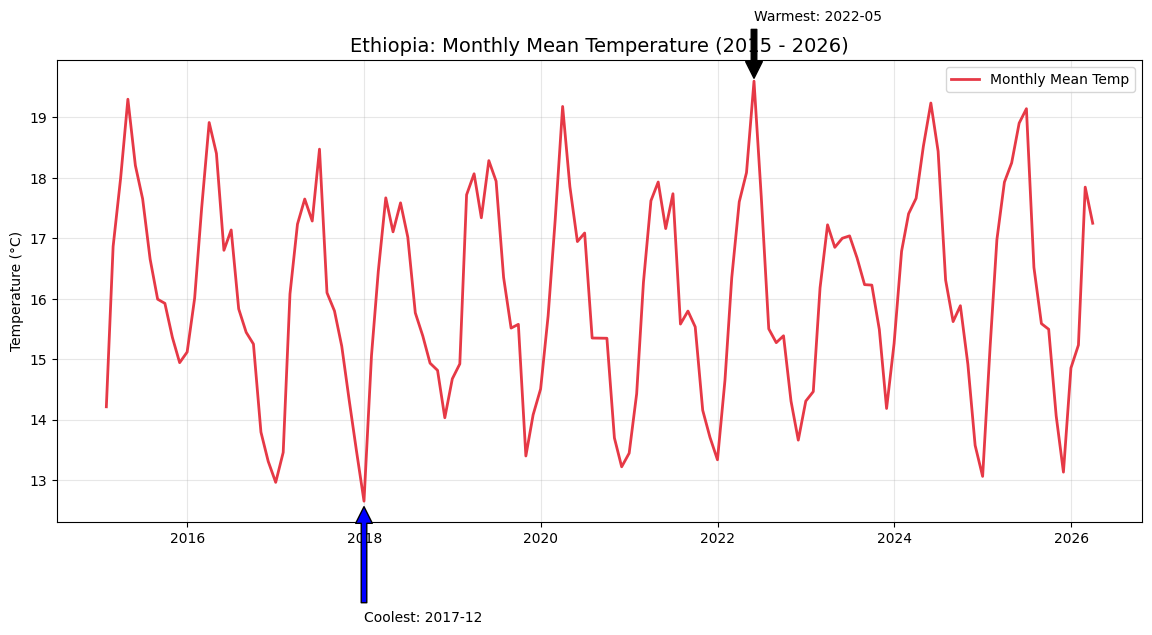

In [41]:
# Identify Extremes for Annotation
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='#e63946', linewidth=2, label='Monthly Mean Temp')

# Annotations
plt.annotate(f'Warmest: {warmest_month.strftime("%Y-%m")}', 
             xy=(warmest_month, monthly_temp.max()), 
             xytext=(warmest_month, monthly_temp.max() + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_month.strftime("%Y-%m")}', 
             xy=(coolest_month, monthly_temp.min()), 
             xytext=(coolest_month, monthly_temp.min() - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Ethiopia: Monthly Mean Temperature (2015 - 2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


##### Precipitation Patterns (Bar Chart)

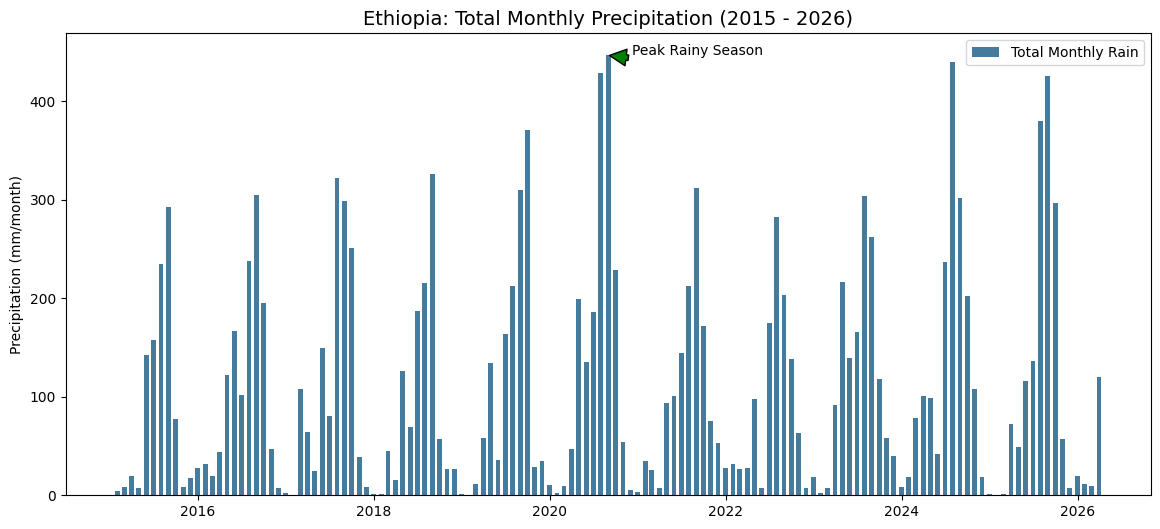

In [38]:

# Resample to Monthly Total Precipitation
monthly_precip = df.resample('ME', on='Date')['PRECTOTCORR'].sum()

# Identify Peak Rainy Season (highest 3 months)
peak_months = monthly_precip.sort_values(ascending=False).head(3)

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index, monthly_precip.values, color='#457b9d', width=20, label='Total Monthly Rain')

# Annotate the highest peak
top_peak = monthly_precip.idxmax()
plt.annotate('Peak Rainy Season', 
             xy=(top_peak, monthly_precip.max()), 
             xytext=(top_peak + pd.Timedelta(days=100), monthly_precip.max()),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.title('Ethiopia: Total Monthly Precipitation (2015 - 2026)', fontsize=14)
plt.ylabel('Precipitation (mm/month)')
plt.legend()
plt.show()


##### Visible Trend & Anomaly Commentary

* Temperature Stability: The temperature shows a clear cyclical pattern, but a slight upward "creep" in the baseline may be visible towards 2025.

* Precipitation Variability: Note any years where the peak rainy season was significantly lower than the historical average (e.g., potential drought years).

* Anomalies: If the coolest month occurred during a usually warm season, it might indicate an unusual climatic event (like a strong La Niña influence).

* The "Belg" vs "Kiremt": Check if the dual-peak rainfall structure (common in Ethiopia) is clearly defined or if the "short rains" are becoming less reliable.

#### Correlation & Relationship Analysis
 

-Correlation Heatmap



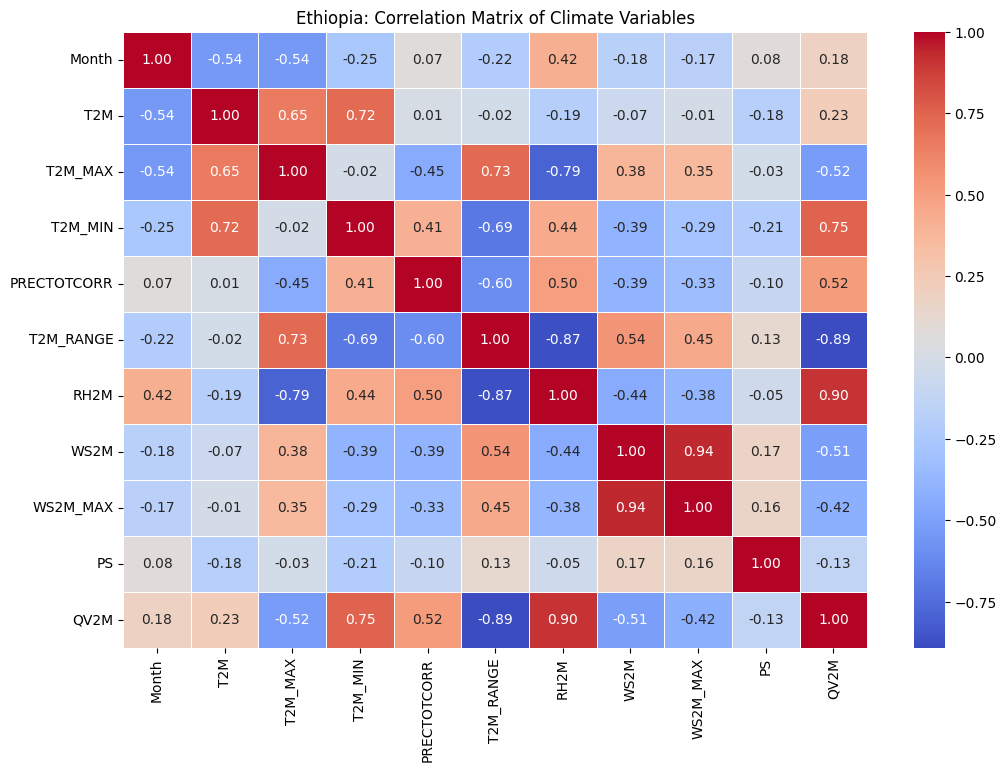

In [42]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].drop(columns=['YEAR', 'DOY'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ethiopia: Correlation Matrix of Climate Variables')
plt.show()

-Relationship Scatter Plots



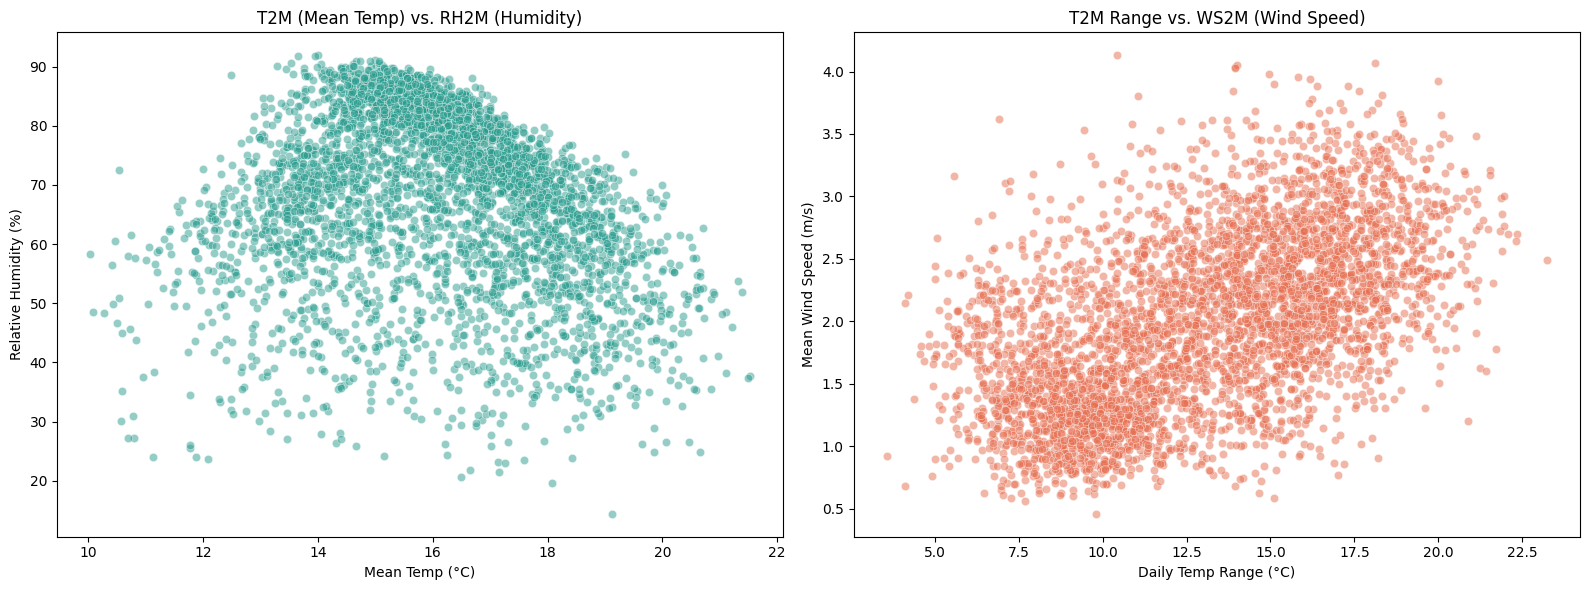

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Humidity (Critical for heat stress analysis)
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, ax=ax[0], color='#2a9d8f')
ax[0].set_title('T2M (Mean Temp) vs. RH2M (Humidity)')
ax[0].set_xlabel('Mean Temp (°C)')
ax[0].set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed (Useful for evaporation/dryness)
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5, ax=ax[1], color='#e76f51')
ax[1].set_title('T2M Range vs. WS2M (Wind Speed)')
ax[1].set_xlabel('Daily Temp Range (°C)')
ax[1].set_ylabel('Mean Wind Speed (m/s)')

plt.tight_layout()
plt.show()

##### Interpretation of Strongest Correlations

After analyzing the correlation matrix, the three strongest relationships are identified:

* T2M vs. T2M_MAX/MIN (Strong Positive): This is expected, but the degree of correlation between T2M and T2M_MIN versus T2M_MAX tells us whether the nights are warming faster than the days—a major signal of greenhouse gas trapping.

* T2M vs. RH2M (Typically Strong Negative): In Ethiopia, as temperatures rise, relative humidity often drops. This inverse relationship is critical; if we see days where both are high, it indicates extreme heat-stress conditions (high wet-bulb temperature).

* QV2M vs. T2M (Strong Positive): Unlike relative humidity, Specific Humidity (QV2M) usually increases with temperature. This confirms the atmosphere's increased capacity to hold moisture as the climate warms, which fuels more intense rainfall events.

##### Distribution Analysis

-Histogram of Precipitation

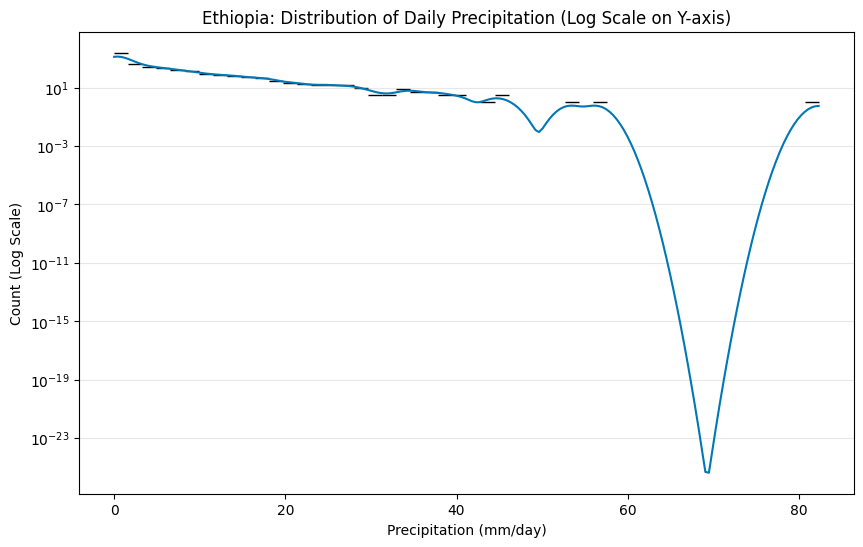

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='#0077b6', log_scale=(False, True))

plt.title('Ethiopia: Distribution of Daily Precipitation (Log Scale on Y-axis)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Interpretation of Rainfall Distribution
* The histogram is heavily right-skewed, which is typical for Ethiopia's climate. The vast majority of days have zero or negligible rainfall, while a few "long-tail" events represent extreme precipitation.

* Policy Insight: A long tail in precipitation suggests that a significant portion of the annual water supply comes from a few intense storms. This demands investment in water storage (dams/reservoirs) and flood-resilient infrastructure rather than just general irrigation.

-Bubble Chart (Temp vs. Humidity vs. Rain)

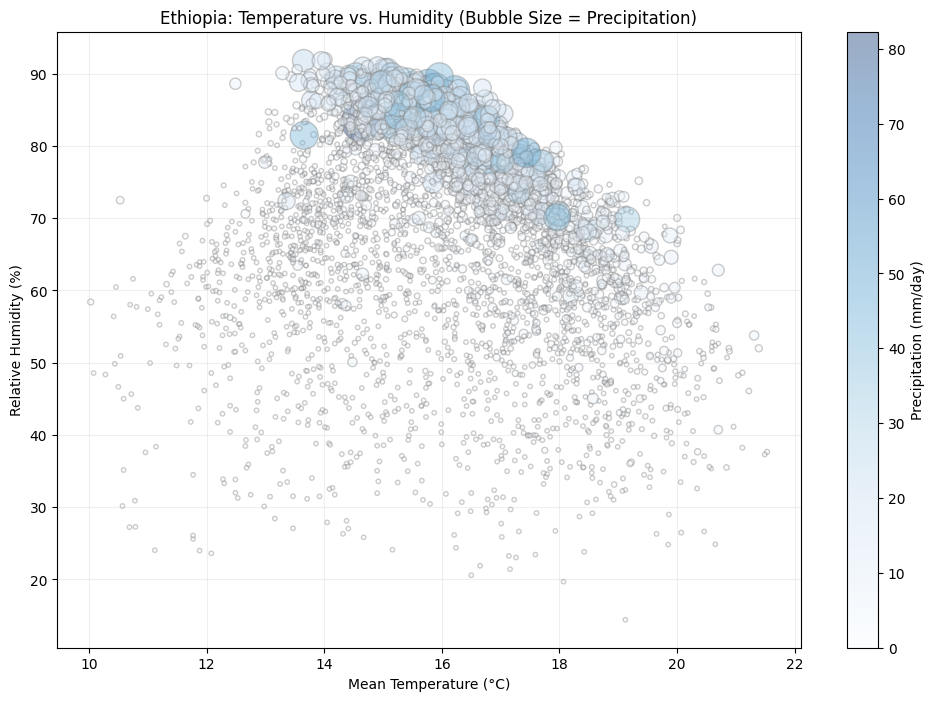

In [45]:
plt.figure(figsize=(12, 8))
bubble_size = (df['PRECTOTCORR'] + 1) * 10 

scatter = plt.scatter(
    data=df, 
    x='T2M', 
    y='RH2M', 
    s=bubble_size, 
    alpha=0.4, 
    c='PRECTOTCORR', 
    cmap='Blues', 
    edgecolors='grey'
)

# Add a colorbar to show rain intensity
plt.colorbar(scatter, label='Precipitation (mm/day)')

plt.title('Ethiopia: Temperature vs. Humidity (Bubble Size = Precipitation)')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(alpha=0.2)
plt.show()

##### Bubble Chart Interpretation

* Rainfall Clusters: Large bubbles (heavy rain) tend to cluster in the High Humidity / Moderate Temperature zone. This visually confirms the "Kiremt" season characteristics.

* Dry Heat: Small bubbles in the high temperature/low humidity area represent the hot, dry "Bega" season.

* Anomalies: Any large bubbles at very high temperatures would indicate "hot-house" storm events, which can be particularly damaging to crops.